# Linear vs vol: the implied-distribution triangle

Three markets carry a distribution of the policy path, and only one prices
its shape:

1. **ZQ futures** — monthly EFFR averages → FedWatch bootstrap → per-meeting
   jump lattice (`RVUtils.MeetingProb.ladder`).
2. **FOMC-dated swaps** — meeting-period fair rates off
   `USD-OIS-Q12xM12STIRT-SERFFX-MIX23` (EFFR leg) and
   `USD-SOFR-1D-Q12xM12STIRT` (SOFR leg) difference directly into the same
   lattice — no bootstrap, no contract-expiry seam
   (`RVUtils.MeetingProb.swap_ladder`).
3. **SR3 options** — the Breeden–Litzenberger RND
   (`RVUtils.ImpliedDistribution`), the full continuous shape.

The linear pair identifies only the MEAN path; parity pins the option mean
to the same forward. So linear-vs-linear differences are measurement noise
plus the FF/SOFR basis, and linear-vs-option differences are **shape** — the
only thing options add, and the only candidate RV.

Taboga (2016, *IREF*) shows equity option RNDs are usually WRONGLY
multi-modal (over-fitting). SR3 is the one underlying where multi-modality
would be structurally real — the FOMC lattice — and the linear tree
independently predicts where any modes must sit. Whether the modes are
*visible* at a given horizon is measured below, not assumed.

The date pair straddles the 2026-07-29 FOMC decision: 07-28 is the eve
(a ~1/3-priced hike pending), 07-31 is fully post-hold. Two contracts:
SFRZ26 (136 days to expiry, the saturated band of the meeting-prob
frontier) and SFRU26 (45 days, the feasible band).

In [1]:
import datetime
import os
import sys

os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")
sys.path.insert(0, r"C:\Users\chris\clee\ARBS-xm")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

SYMBOLS = ["SFRZ26", "SFRU26"]
D0, D1 = datetime.date(2026, 7, 28), datetime.date(2026, 7, 31)
OIS_CURVE = "USD-OIS-Q12xM12STIRT-SERFFX-MIX23"
SOFR_CURVE = "USD-SOFR-1D-Q12xM12STIRT"
BASIS_SMEAR_BP = 3.0            # strict-null convention from the meeting-prob build
N_MEETINGS_SHOWN = 8

## A. The three linear ladders

Same `MeetingLattice` object from three sources. The ZQ ladder needs the
just-expired front contract (ZQN26) force-refreshed into the serff cache —
without it the pending July meeting silently vanishes for its whole event
window. The swap ladders cannot lose a meeting this way.

In [2]:
from RVUtils.MeetingProb.ladder import meeting_ladder, zq_settle_panel
from RVUtils.MeetingProb.swap_ladder import swap_meeting_ladder
from SDRUtils.analytics.fomc import get_current_fixing, load_fomc_schedule
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

fomc = load_fomc_schedule("USD-SOFR-1D")
zq_panel = zq_settle_panel(
    [f"ZQ{c}{y}" for y in (26, 27) for c in "FGHJKMNQUVXZ"])
irs_mdp = IRSwapsMDP(source="BARCHART_STIRF-RL")

ladders = {}
for d in (D0, D1):
    effr = get_current_fixing("USD-OIS", d)
    sofr = get_current_fixing("USD-SOFR-1D", d)
    ladders[(d, "ZQ")] = meeting_ladder(d, zq_panel, fomc)
    for tag, curve, base in (("OIS-swap", OIS_CURVE, effr),
                             ("SOFR-swap", SOFR_CURVE, sofr)):
        pricer = irs_mdp.get_pricer(dict(curve_name=curve, timestamp=d))
        ladders[(d, tag)] = swap_meeting_ladder(d, pricer, fomc, base)
    print(f"{d}: EFFR {effr*100:.2f}  SOFR {sofr*100:.2f}  "
          + "  ".join(f"{t}:{len(ladders[(d, t)])} mtgs"
                      for t in ("ZQ", "OIS-swap", "SOFR-swap")), flush=True)

SOURCES = ["ZQ", "OIS-swap", "SOFR-swap"]

def ladder_frame(d):
    rows = {}
    for tag in SOURCES:
        for m in ladders[(d, tag)][:N_MEETINGS_SHOWN]:
            rows.setdefault(m.effective, {})[f"jump_{tag}"] = round(m.jump_bp, 1)
            rows.setdefault(m.effective, {})[f"q_{tag}"] = round(m.q, 3)
    df = pd.DataFrame(rows).T.sort_index()
    df.index.name = "meeting_effective"
    return df

for d in (D0, D1):
    print(f"\n=== per-meeting jumps (bp) and lattice q, as of {d} ===")
    print(ladder_frame(d).to_string())

2026-07-28: EFFR 3.63  SOFR 3.65  ZQ:10 mtgs  OIS-swap:12 mtgs  SOFR-swap:12 mtgs


2026-07-31: EFFR 3.63  SOFR 3.65  ZQ:10 mtgs  OIS-swap:11 mtgs  SOFR-swap:11 mtgs



=== per-meeting jumps (bp) and lattice q, as of 2026-07-28 ===
                   jump_ZQ   q_ZQ  jump_OIS-swap  q_OIS-swap  jump_SOFR-swap  q_SOFR-swap
meeting_effective                                                                        
2026-07-29             8.0  0.321           10.6       0.424            10.4        0.415
2026-09-16            16.0  0.640           12.2       0.487            12.8        0.514
2026-10-28             7.5  0.299           10.6       0.422            10.8        0.432
2026-12-09             8.8  0.350            6.9       0.277             8.3        0.331
2027-01-27             4.2  0.167            6.4       0.254             5.1        0.204
2027-03-17             5.2  0.207            4.1       0.165             3.5        0.140
2027-04-28             2.2  0.089            1.4       0.055             2.3        0.093
2027-06-09             0.0  0.000            1.4       0.057             0.8        0.031

=== per-meeting jumps (bp) and latt

In [3]:
# Tie-out between the linear sources: same object, three measurements.
tie_rows = []
for d in (D0, D1):
    f = ladder_frame(d)
    for a, b in (("ZQ", "OIS-swap"), ("ZQ", "SOFR-swap"), ("OIS-swap", "SOFR-swap")):
        gap = (f[f"jump_{a}"] - f[f"jump_{b}"]).dropna()
        tie_rows.append({"as_of": d, "pair": f"{a} vs {b}", "n_meetings": len(gap),
                         "mean_gap_bp": round(gap.mean(), 2),
                         "max_abs_gap_bp": round(gap.abs().max(), 2)})
tieout = pd.DataFrame(tie_rows)
print(tieout.to_string(index=False))

f0 = ladder_frame(D0)
cum0 = {t: f0[f"jump_{t}"].iloc[:2].sum() for t in SOURCES}
print(f"\nAttribution vs level, {D0} (pending July + Sep): cumulative "
      f"post-Sep move  " + "  ".join(f"{t}:{v:.0f}bp" for t, v in cum0.items()))
print("The cumulative level agrees to ~1bp while the July/Sep SPLIT differs "
      "by up to ~4bp — linear sources agree on the mean path and disagree "
      "only on attribution, the exchangeability theme from the meeting-prob "
      "study, now visible BETWEEN two linear markets.")

     as_of                  pair  n_meetings  mean_gap_bp  max_abs_gap_bp
2026-07-28        ZQ vs OIS-swap           8        -0.21             3.8
2026-07-28       ZQ vs SOFR-swap           8        -0.26             3.3
2026-07-28 OIS-swap vs SOFR-swap           8        -0.05             1.4
2026-07-31        ZQ vs OIS-swap           7        -0.14             3.4
2026-07-31       ZQ vs SOFR-swap           7        -0.40             4.1
2026-07-31 OIS-swap vs SOFR-swap           8        -0.14             2.0

Attribution vs level, 2026-07-28 (pending July + Sep): cumulative post-Sep move  ZQ:24bp  OIS-swap:23bp  SOFR-swap:23bp
The cumulative level agrees to ~1bp while the July/Sep SPLIT differs by up to ~4bp — linear sources agree on the mean path and disagree only on attribution, the exchangeability theme from the meeting-prob study, now visible BETWEEN two linear markets.


## A2. The FedWatch table, from all three sources

Composing each ladder's independent two-point meetings gives the
conditional target-range matrix — the CME FedWatch screen — from each
source. ZQ reproduces the published tool; the swap curves give the same
table with no bootstrap.

In [4]:
def fedwatch_table(ladder, base_rate_pct, n=N_MEETINGS_SHOWN):
    """Cumulative-move distribution at each meeting -> bucket matrix (%)."""
    base_lo = int(np.floor(base_rate_pct * 100 / 25.0) * 25)  # eg 350
    dist = {0: 1.0}
    rows = {}
    for m in ladder[:n]:
        new = {}
        for moves, p in dist.items():
            for k, pk in m.probs.items():
                new[moves + k] = new.get(moves + k, 0.0) + p * pk
        dist = new
        rows[m.effective] = {
            f"{base_lo + 25 * mv}-{base_lo + 25 * mv + 25}": round(100 * p, 1)
            for mv, p in sorted(dist.items())}
    df = pd.DataFrame(rows).T.fillna(0.0)
    df.index.name = "meeting"
    return df[sorted(df.columns, key=lambda c: int(c.split("-")[0]))]

for d in (D0, D1):
    effr = get_current_fixing("USD-OIS", d) * 100
    for tag in SOURCES:
        t = fedwatch_table(ladders[(d, tag)], effr)
        print(f"\n=== conditional meeting probabilities, {tag}, as of {d} ===")
        print(t.to_string())


=== conditional meeting probabilities, ZQ, as of 2026-07-28 ===
            350-375  375-400  400-425  425-450  450-475  475-500  500-525  525-550
meeting                                                                           
2026-07-29     67.9     32.1      0.0      0.0      0.0      0.0      0.0      0.0
2026-09-16     24.4     55.0     20.5      0.0      0.0      0.0      0.0      0.0
2026-10-28     17.1     45.9     30.8      6.1      0.0      0.0      0.0      0.0
2026-12-09     11.1     35.8     36.1     14.8      2.1      0.0      0.0      0.0
2027-01-27      9.3     31.7     36.1     18.3      4.3      0.4      0.0      0.0
2027-03-17      7.4     27.1     35.2     22.0      7.2      1.2      0.1      0.0
2027-04-28      6.7     25.3     34.4     23.2      8.5      1.7      0.2      0.0
2027-06-09      6.7     25.3     34.4     23.2      8.5      1.7      0.2      0.0

=== conditional meeting probabilities, OIS-swap, as of 2026-07-28 ===
            350-375  375-400  400-

## B. The terminal object: BL RND vs the meeting trees

Everything now lives on each contract's settlement-rate axis. Both trees
are pushed through the settlement transform (`split_meetings` +
`AtomEngine`, mean-pinned to the option forward), so the FF/SOFR basis
LEVEL drops out by construction and all three curves share one mean. What
differs is shape.

Extraction honesty: the default JPM raw-premium workflow gates strikes on
open interest. The 07-31 session has no OI published yet, which silently
swaps in a SABR MODEL density — so wherever the default falls back, the
OI-gate-free raw-premium variant is used instead, and the variant actually
used is recorded per (symbol, date) below.

In [5]:
from MDP.STIRFutures.STIRFutureOptionMDP import STIRFutureOptionMDP
from RVUtils.ImpliedDistribution import SFRImpliedDistribution
from RVUtils.MeetingProb.atoms import AtomEngine, split_meetings

stirfo_mdp = STIRFutureOptionMDP(source="BARCHART_STIRFO-QL")
dist_default = SFRImpliedDistribution()
dist_no_oi = SFRImpliedDistribution(raw_market_open_interest_min=0)

def extract_best(smile):
    """Default extraction, unless the OI gate forced the SABR-model fallback."""
    snap = dist_default.extract(smile, run_gm=False)
    if any("fell back" in w for w in snap.bl_result.warnings):
        return dist_no_oi.extract(smile, run_gm=False), "raw-premium, no OI gate"
    return snap, "default (JPM raw-premium, OI>=100)"

smiles, snaps = {}, {}
for sym in SYMBOLS:
    for d in (D0, D1):
        smiles[(sym, d)] = stirfo_mdp.fetch_sabr_smile({
            "symbol": sym, "as_of": d, "strike_offsets_bps": "listed"})
        snaps[(sym, d)], variant = extract_best(smiles[(sym, d)])
        bl = snaps[(sym, d)].bl_result
        assert not any("fell back" in w for w in bl.warnings), \
            f"{sym} {d}: still a model density"
        print(f"{sym} {d} [{variant}]: forward {bl.input.forward_rate:.3f}%  "
              f"std {bl.std_rate*100:.1f}bp  fwd_resid {bl.forward_residual_bp:+.2f}bp  "
              f"mass {bl.pre_normalization_mass:.3f}  ghost {bl.ghost_mass_fraction:.3f}",
              flush=True)
        for w in bl.warnings:
            print(f"   warn: {w}")

# Extraction-robustness: on the date where both variants run on observed
# premiums, how much does the strike filter move the recovered width?
print()
for sym in SYMBOLS:
    b_gate = dist_default.extract(smiles[(sym, D0)], run_gm=False).bl_result
    b_raw = dist_no_oi.extract(smiles[(sym, D0)], run_gm=False).bl_result
    print(f"{sym} {D0}: std {b_gate.std_rate*100:.1f}bp (OI-gated) vs "
          f"{b_raw.std_rate*100:.1f}bp (ungated) -> width moves "
          f"{abs(b_gate.std_rate - b_raw.std_rate)*100:.1f}bp with the filter")

SFRZ26 2026-07-28 [default (JPM raw-premium, OI>=100)]: forward 4.105%  std 52.5bp  fwd_resid -1.09bp  mass 1.001  ghost 0.008


   warn: fitted C(K) is non-monotone: max dC/dK = +0.00013 > 0
   warn: negative density mass clipped (0.73% of total)
SFRZ26 2026-07-31 [raw-premium, no OI gate]: forward 4.080%  std 43.5bp  fwd_resid +1.92bp  mass 0.997  ghost 0.007


   warn: fitted C(K) breaches the delta bound: min dC/dK = -0.98854 < -DF = -0.98609
   warn: negative density mass clipped (2.09% of total)
SFRU26 2026-07-28 [default (JPM raw-premium, OI>=100)]: forward 3.960%  std 32.3bp  fwd_resid -2.06bp  mass 1.024  ghost 0.004


   warn: fitted C(K) is non-monotone: max dC/dK = +0.00809 > 0
   warn: fitted C(K) breaches the delta bound: min dC/dK = -0.99729 < -DF = -0.99533
   warn: negative density mass clipped (2.55% of total)
   warn: pre-normalization mass 1.0236 exceeds 1: butterfly arbitrage in the fitted call curve
   warn: RND mean 3.9394% misses the forward 3.9600% by -2.06bp (martingale tie-out)
SFRU26 2026-07-31 [raw-premium, no OI gate]: forward 3.885%  std 41.6bp  fwd_resid -4.33bp  mass 1.053  ghost 0.011


   warn: fitted C(K) is non-monotone: max dC/dK = +0.01540 > 0
   warn: fitted C(K) breaches the delta bound: min dC/dK = -1.00054 < -DF = -0.99574
   warn: negative density mass clipped (4.91% of total)
   warn: pre-normalization mass 1.0534 exceeds 1: butterfly arbitrage in the fitted call curve
   warn: RND mean 3.8417% misses the forward 3.8850% by -4.33bp (martingale tie-out)

SFRZ26 2026-07-28: std 52.5bp (OI-gated) vs 51.1bp (ungated) -> width moves 1.4bp with the filter
SFRU26 2026-07-28: std 32.3bp (OI-gated) vs 33.5bp (ungated) -> width moves 1.2bp with the filter


In [6]:
def tree(sym, d, tag):
    """(unique atoms, probs, smear_bp, cm) on the option forward."""
    cm = split_meetings(d, sym, ladders[(d, tag)])
    eng = AtomEngine(cm)
    fwd = snaps[(sym, d)].bl_result.input.forward_rate
    rates, probs = eng.rates_probs(fwd)
    uniq = {}
    for r, p in zip(np.round(rates, 6), probs):
        uniq[r] = uniq.get(r, 0.0) + p
    rates = np.array(sorted(uniq))
    probs = np.array([uniq[r] for r in rates])
    smear = float(np.sqrt(cm.unresolved_var_bp2 + BASIS_SMEAR_BP ** 2))
    return rates, probs, smear, cm

def mix_pdf(x, rates, probs, smear_bp):
    s = smear_bp / 100.0
    return sum(p * np.exp(-0.5 * ((np.asarray(x) - r) / s) ** 2)
               / (s * np.sqrt(2 * np.pi)) for r, p in zip(rates, probs))

def mix_cdf(x, rates, probs, smear_bp):
    from scipy.stats import norm
    s = smear_bp / 100.0
    x = np.asarray(x, dtype=float)
    return sum(p * norm.cdf((x - r) / s) for r, p in zip(rates, probs))

def tree_std_bp(rates, probs, smear_bp):
    mu = float(np.dot(probs, rates))
    return float(np.sqrt(np.dot(probs, (np.asarray(rates) - mu) ** 2) * 1e4
                         + smear_bp ** 2))

stats_rows = []
for sym in SYMBOLS:
    for d in (D0, D1):
        bl = snaps[(sym, d)].bl_result
        bkm = snaps[(sym, d)].bkm_result
        for tag in ("ZQ", "SOFR-swap"):
            rates, probs, smear, cm = tree(sym, d, tag)
            w = [r.weight for r in cm.resolved]
            stats_rows.append({
                "symbol": sym, "as_of": d, "source": tag,
                "dte": (cm.expiry - d).days,
                "n_resolved": cm.n_resolved, "atoms": len(rates),
                "smear_bp": round(smear, 1),
                "tree_std_bp": round(tree_std_bp(rates, probs, smear), 1),
                "bl_std_bp": round(bl.std_rate * 100, 1),
                "bkm_std_bp": round(bkm.std_rate * 100, 1) if bkm else np.nan,
                "resolved_ceiling_bp": round(
                    float(np.sqrt(sum((wi * 12.5) ** 2 for wi in w))), 1),
            })
tree_stats = pd.DataFrame(stats_rows)
print(tree_stats.to_string(index=False))

for sym in SYMBOLS:
    row = tree_stats[(tree_stats.symbol == sym) & (tree_stats.as_of == D0)
                     & (tree_stats.source == "ZQ")].iloc[0]
    print(f"\n{sym} ({row['dte']:.0f} dte): surface {row['bl_std_bp']:.0f}bp vs "
          f"tree {row['tree_std_bp']:.0f}bp -> "
          f"{row['bl_std_bp'] - row['tree_std_bp']:+.0f}bp of width the lattice "
          f"cannot carry.")
print("\nThe off-lattice premium shrinks toward expiry exactly as the "
      "meeting-prob frontier measured: the saturated band prices roughly "
      "double the tree, the feasible band much less.")

symbol      as_of    source  dte  n_resolved  atoms  smear_bp  tree_std_bp  bl_std_bp  bkm_std_bp  resolved_ceiling_bp
SFRZ26 2026-07-28        ZQ  136           4      5       5.8         24.2       52.5         NaN                 25.0
SFRZ26 2026-07-28 SOFR-swap  136           4      5       6.2         25.3       52.5         NaN                 25.0
SFRZ26 2026-07-31        ZQ  133           3      4       6.6         21.9       43.5         NaN                 21.7
SFRZ26 2026-07-31 SOFR-swap  133           3      4       6.8         22.3       43.5         NaN                 21.7
SFRU26 2026-07-28        ZQ   45           1      2      13.8         18.1       32.3         NaN                 12.5
SFRU26 2026-07-28 SOFR-swap   45           1      2      14.5         19.0       32.3         NaN                 12.5
SFRU26 2026-07-31        ZQ   42           0      1      13.9         13.9       41.6         NaN                  0.0
SFRU26 2026-07-31 SOFR-swap   42           0    

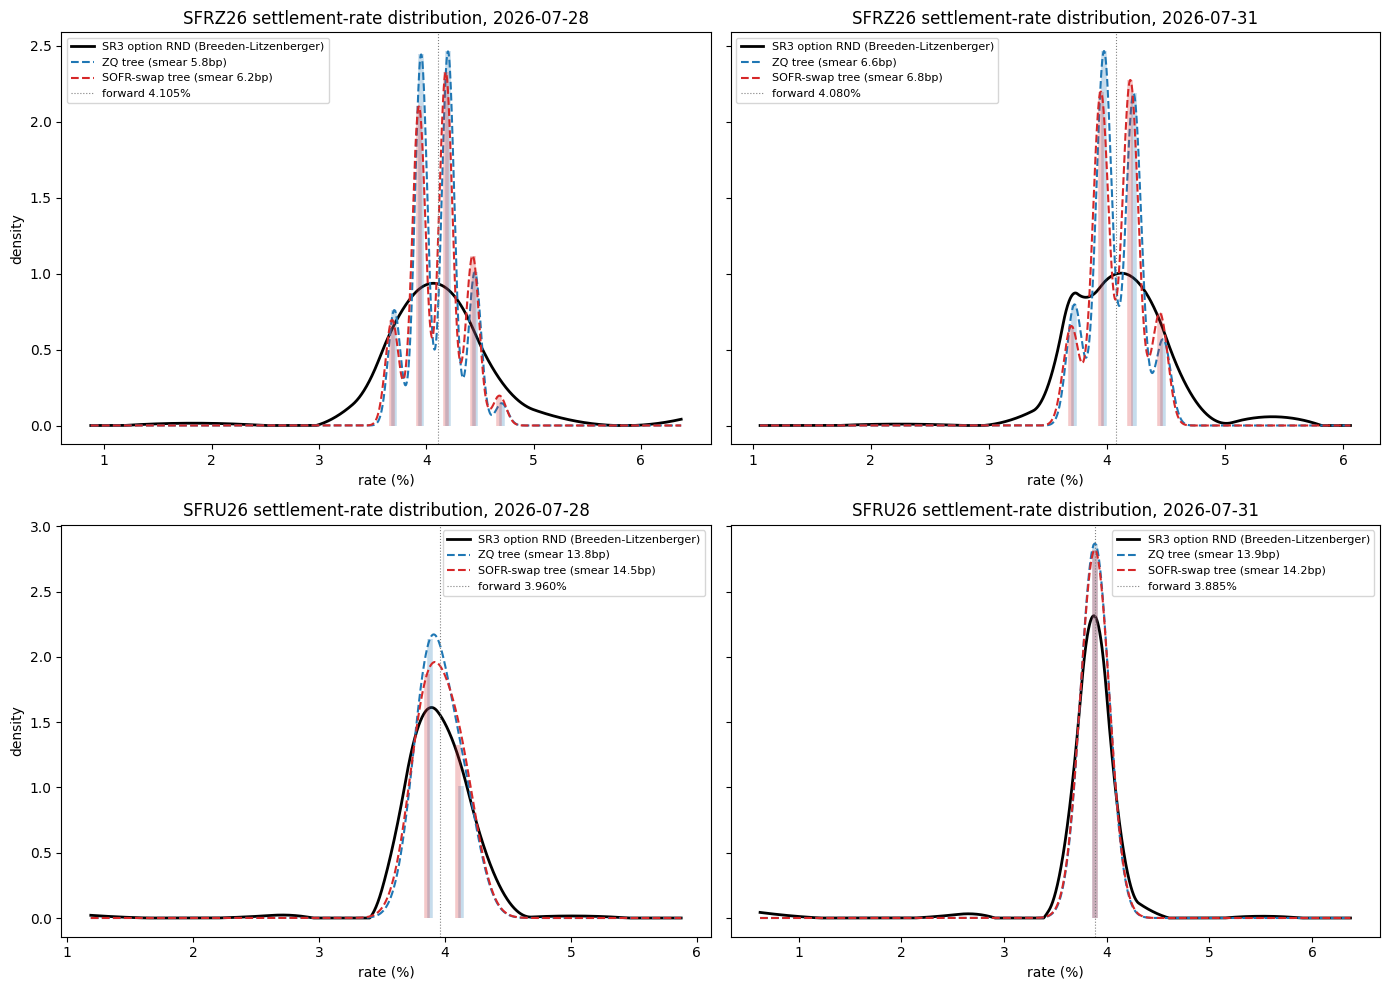

In [7]:
fig, axes = plt.subplots(len(SYMBOLS), 2, figsize=(14, 5 * len(SYMBOLS)),
                         sharey="row")
for i, sym in enumerate(SYMBOLS):
    for ax, d in zip(axes[i], (D0, D1)):
        bl = snaps[(sym, d)].bl_result
        grid = bl.strike_grid_rate
        ax.plot(grid, bl.rnd_density, lw=2, color="k",
                label="SR3 option RND (Breeden-Litzenberger)")
        for tag, color in (("ZQ", "tab:blue"), ("SOFR-swap", "tab:red")):
            rates, probs, smear, _ = tree(sym, d, tag)
            ax.plot(grid, mix_pdf(grid, rates, probs, smear), "--", color=color,
                    lw=1.5, label=f"{tag} tree (smear {smear:.1f}bp)")
            dens_at = mix_pdf(rates, rates, probs, smear)
            ax.vlines(rates, 0, probs / probs.max() * dens_at.max(),
                      color=color, alpha=0.25, lw=4)
        ax.axvline(bl.input.forward_rate, color="gray", lw=0.8, ls=":",
                   label=f"forward {bl.input.forward_rate:.3f}%")
        ax.set_title(f"{sym} settlement-rate distribution, {d}")
        ax.set_xlabel("rate (%)")
        ax.legend(fontsize=8)
    axes[i][0].set_ylabel("density")
plt.tight_layout()
plt.show()

In [8]:
# The Taboga check, measured not assumed: local maxima of the BL density vs
# the nearest lattice atom. Structural multi-modality would land ON atoms.
from scipy.signal import argrelextrema

mode_rows = []
for sym in SYMBOLS:
    for d in (D0, D1):
        bl = snaps[(sym, d)].bl_result
        dens, grid = bl.rnd_density, bl.strike_grid_rate
        idx = argrelextrema(dens, np.greater, order=8)[0]
        idx = [i for i in idx if dens[i] > 0.10 * dens.max()]
        rates, probs, smear, cm = tree(sym, d, "ZQ")
        for i in idx:
            gap = (grid[i] - np.asarray(rates)) * 100
            j = int(np.abs(gap).argmin())
            mode_rows.append({"symbol": sym, "as_of": d,
                              "mode_rate": round(grid[i], 3),
                              "nearest_atom": round(rates[j], 3),
                              "gap_bp": round(gap[j], 1),
                              "smear_bp": round(smear, 1),
                              "n_resolved": cm.n_resolved})
modes = pd.DataFrame(mode_rows)
print(modes.to_string(index=False))

n_modes = modes.groupby(["symbol", "as_of"]).size()
informative = modes[modes.n_resolved > 0]      # 0 resolved -> one atom AT the
aligned = float(informative["gap_bp"].abs().le(6).mean())  # forward: vacuous
multi = int((n_modes > 1).sum())
print(f"\n{multi} of {len(n_modes)} (symbol, date) cells are multi-modal; "
      f"{aligned:.0%} of modes with a non-trivial lattice sit within 6bp of "
      "an atom. But the mode COUNT is not stable across the two extraction "
      "variants (the OI-gated 07-28 density is unimodal, the ungated 07-31 "
      "density is bimodal on-atom), while the recovered WIDTH moves only "
      "~1bp between them (printed in section B). That is Taboga's result "
      "operating as designed: jaggedness is an extraction artefact even "
      "where modes are structurally real, and with 6-14bp of "
      "unresolved-meeting smear the calendar's modes only crystallize "
      "robustly inside the final month (<30 dte, where the meeting-prob "
      "frontier found 0% saturation). At these vintages the width and the "
      "tails, not the modes, carry the lattice information.")

symbol      as_of  mode_rate  nearest_atom  gap_bp  smear_bp  n_resolved
SFRZ26 2026-07-28      4.067         3.952    11.4       5.8           4
SFRZ26 2026-07-31      3.734         3.725     0.9       6.6           3
SFRZ26 2026-07-31      4.119         4.225   -10.6       6.6           3
SFRU26 2026-07-28      3.894         3.880     1.4      13.8           1
SFRU26 2026-07-31      3.875         3.885    -1.0      13.9           0

1 of 4 (symbol, date) cells are multi-modal; 50% of modes with a non-trivial lattice sit within 6bp of an atom. But the mode COUNT is not stable across the two extraction variants (the OI-gated 07-28 density is unimodal, the ungated 07-31 density is bimodal on-atom), while the recovered WIDTH moves only ~1bp between them (printed in section B). That is Taboga's result operating as designed: jaggedness is an extraction artefact even where modes are structurally real, and with 6-14bp of unresolved-meeting smear the calendar's modes only crystallize robustly

## C. The change across the July decision

07-28 → 07-31: the pending July meeting resolves (hold). The linear legs
show the mechanics — the front-period level collapses (~-8bp) while
later-meeting jumps inflate (probability migrates out the strip, +1 to
+4bp per meeting). Parity forces the option mean to follow the same
forward; anything else that moved is shape.

=== per-meeting jump changes, 07-28 -> 07-31 (bp) ===
                   jump_ZQ  jump_OIS-swap  jump_SOFR-swap
meeting_effective                                        
2026-07-29            -7.7            NaN             NaN
2026-09-16             0.0            4.3             3.0
2026-10-28             0.5            0.8             1.3
2026-12-09             2.7            1.3             1.9
2027-01-27             2.4            2.7             2.2
2027-03-17             2.0            1.5             2.1
2027-04-28             1.1            2.3             1.6
2027-06-09             1.4           -0.9             1.1
(July NaN on the swap legs: in-progress period, deliberately never priced; the ZQ row shows the -7.7bp resolution collapse directly.)

SFRZ26: forward 4.105 -> 4.080 (-2.5bp) | BL mean 4.094 -> 4.099 | BL std 52.5 -> 43.5bp

SFRU26: forward 3.960 -> 3.885 (-7.5bp) | BL mean 3.939 -> 3.842 | BL std 32.3 -> 41.6bp

The mean moved with the forward on both contracts (

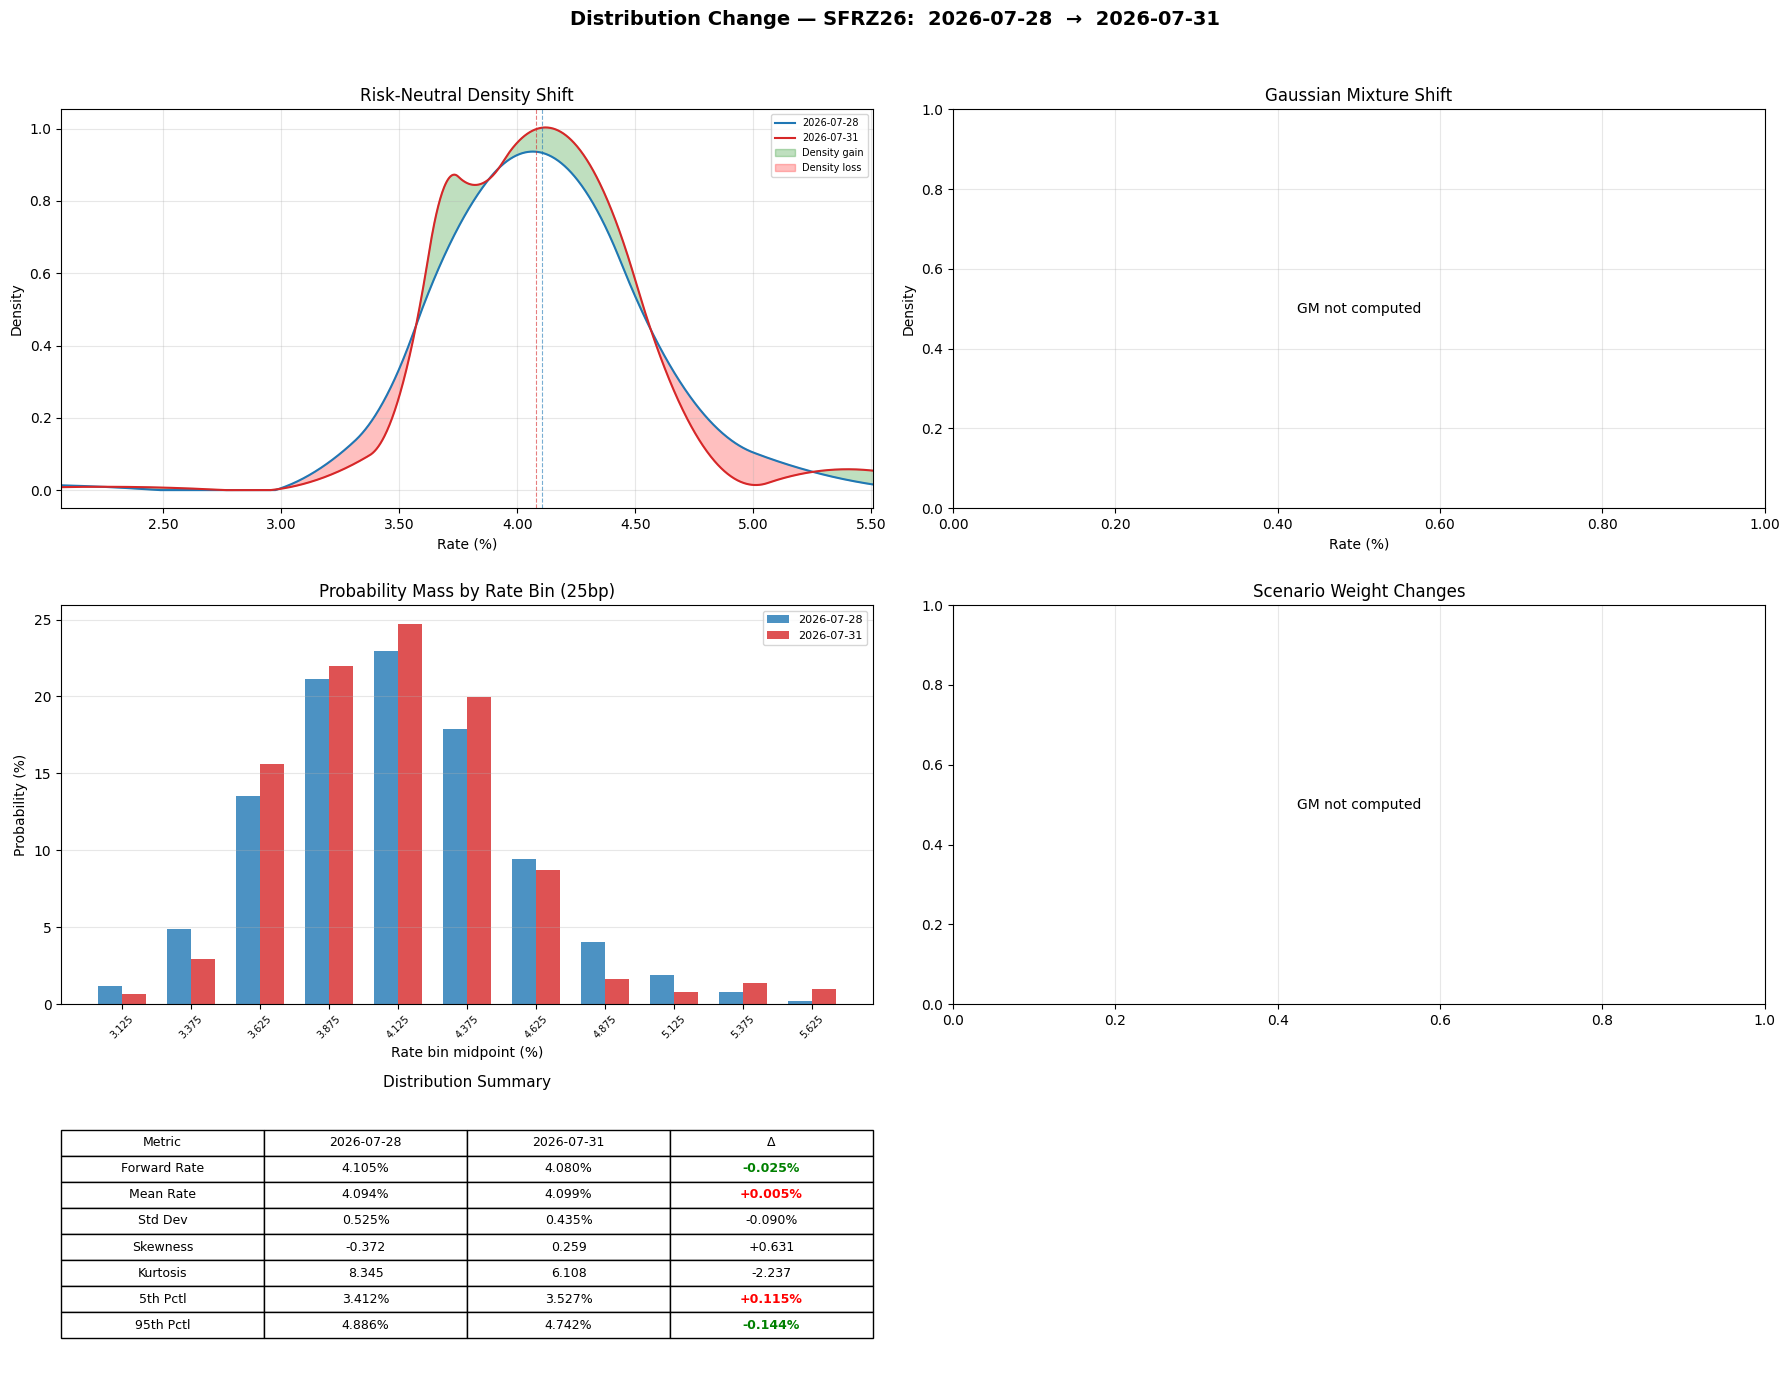

In [9]:
from RVUtils.ImpliedDistribution import plot_distribution_change

delta = (ladder_frame(D1).filter(like="jump_")
         - ladder_frame(D0).filter(like="jump_")).dropna(how="all")
print("=== per-meeting jump changes, 07-28 -> 07-31 (bp) ===")
print(delta.to_string())
print("(July NaN on the swap legs: in-progress period, deliberately never "
      "priced; the ZQ row shows the -7.7bp resolution collapse directly.)")

for sym in SYMBOLS:
    b0, b1 = snaps[(sym, D0)].bl_result, snaps[(sym, D1)].bl_result
    print(f"\n{sym}: forward {b0.input.forward_rate:.3f} -> "
          f"{b1.input.forward_rate:.3f} ({(b1.input.forward_rate - b0.input.forward_rate)*100:+.1f}bp)"
          f" | BL mean {b0.mean_rate:.3f} -> {b1.mean_rate:.3f}"
          f" | BL std {b0.std_rate*100:.1f} -> {b1.std_rate*100:.1f}bp")
print("\nThe mean moved with the forward on both contracts (parity: the mean "
      "channel is dead); the width change is the shape story.")

fig = plot_distribution_change(snaps[("SFRZ26", D0)], snaps[("SFRZ26", D1)])
plt.show()

## D. Where the option distribution disagrees with the linear tree

Per-25bp-node probabilities: option (BL CDF between atom midpoints) minus
tree (smeared mixture over the same edges), under the strict smear. This is
the model-space version of the boundary-digital decomposition from the
meeting-prob study: mode-flank asymmetry = per-meeting reallocation
(channel 1); both outer tails rich = off-lattice premium (channel 2).

In [10]:
def divergence(sym, d, tag="ZQ"):
    bl = snaps[(sym, d)].bl_result
    r, p, smear, _ = tree(sym, d, tag)
    edges = np.concatenate([[r[0] - 0.125], (r[:-1] + r[1:]) / 2,
                            [r[-1] + 0.125]])
    cdf_opt = np.interp(edges, bl.strike_grid_rate, bl.rnd_cumulative,
                        left=0.0, right=1.0)
    p_opt = np.diff(cdf_opt)
    cdf_tree = mix_cdf(edges, r, p, smear)
    p_tree = np.diff(cdf_tree)
    rows = [{"node": round(rk, 3), "p_tree": round(p_tree[k], 3),
             "p_opt": round(p_opt[k], 3),
             "gap_pp": round(100 * (p_opt[k] - p_tree[k]), 1)}
            for k, rk in enumerate(r)]
    rows.append({"node": "below-lattice", "p_tree": round(float(cdf_tree[0]), 3),
                 "p_opt": round(float(cdf_opt[0]), 3),
                 "gap_pp": round(100 * (float(cdf_opt[0]) - float(cdf_tree[0])), 1)})
    rows.append({"node": "above-lattice",
                 "p_tree": round(float(1 - cdf_tree[-1]), 3),
                 "p_opt": round(float(1 - cdf_opt[-1]), 3),
                 "gap_pp": round(100 * ((1 - float(cdf_opt[-1]))
                                        - (1 - float(cdf_tree[-1]))), 1)})
    return pd.DataFrame(rows)

tails = {}
for sym in SYMBOLS:
    for d in (D0, D1):
        dv = divergence(sym, d)
        print(f"\n=== node probabilities, option vs ZQ tree, {sym} {d} ===")
        print(dv.to_string(index=False))
        t = dv[dv.node.isin(["below-lattice", "above-lattice"])]["gap_pp"]
        tails[(sym, d)] = tuple(t.values)

print("\n=== off-lattice tail richness (option minus tree, pp) ===")
for (sym, d), (below, above) in tails.items():
    both = below > 0.5 and above > 0.5
    print(f"{sym} {d}: below {below:+.1f}  above {above:+.1f}  "
          f"{'both tails rich -> channel-2 signature' if both else 'mixed'}")
print("\nBoth contracts, both dates, price BOTH off-lattice tails above the "
      "strict tree — the one-sided off-lattice premium (channel 2), exactly "
      "where the meeting-prob frontier puts these vintages. The per-meeting "
      "convergence channel only opens inside ~60 days, and by then the swap "
      "ladder is the cleaner linear leg to trade it against.")


=== node probabilities, option vs ZQ tree, SFRZ26 2026-07-28 ===
         node  p_tree  p_opt  gap_pp
        3.702   0.114  0.164     5.1
        3.952   0.354  0.224   -13.0
        4.202   0.358  0.221   -13.7
        4.452   0.149  0.152     0.3
        4.702   0.023  0.073     5.0
below-lattice   0.002  0.105    10.3
above-lattice   0.000  0.060     5.9

=== node probabilities, option vs ZQ tree, SFRZ26 2026-07-31 ===
         node  p_tree  p_opt  gap_pp
        3.725   0.137  0.201     6.5
        3.975   0.400  0.233   -16.7
        4.225   0.357  0.239   -11.8
        4.475   0.100  0.157     5.7
below-lattice   0.004  0.082     7.8
above-lattice   0.003  0.088     8.5

=== node probabilities, option vs ZQ tree, SFRU26 2026-07-28 ===
         node  p_tree  p_opt  gap_pp
         3.88   0.488  0.386   -10.2
         4.13   0.326  0.284    -4.2
below-lattice   0.126  0.218     9.2
above-lattice   0.061  0.112     5.1

=== node probabilities, option vs ZQ tree, SFRU26 2026-07-31 

## E. The ICS anchor: putting the mean gap back on the table

Sections B–D mean-pinned both trees to the option forward, which kills the
level channel by construction. But CME LISTS the level: the FF-vs-SR3
inter-commodity spread — for SFRZ26, `0.5·ZQF27 + 0.5·ZQG27 − SR3Z26` at a
10:6 leg ratio ($250/bp DV01-neutral both sides), quoted as
`SOFR rate − FF rate` ("STIR ICS on Globex", CME, June 2026). So the mean
gap is an observable with its own order book, and it decomposes:

`ICS = SOFR-EFFR basis + compounding wedge + calendar proxy wedge + residual`

* **basis** — SR3 compounds SOFR, ZQ averages EFFR (spot ~+2bp);
* **compounding** — compounded vs arithmetic: ~r²·(D−1)/720 (~+2bp at 4%);
* **proxy wedge** — Jan+Feb is the exchange's IMM proxy for the true
  Dec16→Mar17 window; the same lattice prices the difference (~+0.3bp when
  hikes are priced);
* **residual** — whatever is left. For a DECEMBER quarterly the window
  contains the year-end turn, when SOFR prints spike — so a positive
  residual is at least partly the turn premium, not free money.

In [11]:
from RVUtils.MeetingProb.ics import (
    compounding_wedge_bp,
    ff_conditional_atoms,
    ics_blend_contracts,
    ics_spread_bp,
    proxy_wedge_bp,
)
from MDP.STIRFutures._sofr_option_contracts import quarterly_reference_window

ICS_SYM = "SFRZ26"
blend = ics_blend_contracts(ICS_SYM)
S_win, E_win = quarterly_reference_window(ICS_SYM)
win_days = (E_win - S_win).days
print(f"{ICS_SYM} ICS blend: {blend}, reference window {S_win} -> {E_win} "
      f"({win_days} days)")

ics_rows, ff_view = [], {}
for d in (D0, D1):
    ffp = [float(zq_panel.loc[:pd.Timestamp(d), c].iloc[-1]) for c in blend]
    fwd = snaps[(ICS_SYM, d)].bl_result.input.forward_rate
    spread = ics_spread_bp(100.0 - fwd, ffp)
    basis = (get_current_fixing("USD-SOFR-1D", d)
             - get_current_fixing("USD-OIS", d)) * 1e4
    comp = compounding_wedge_bp(fwd, win_days)
    wedge = proxy_wedge_bp(ladders[(d, "ZQ")], ICS_SYM)
    resid = spread - basis - comp + wedge
    effr = get_current_fixing("USD-OIS", d) * 100
    ff_view[d] = ff_conditional_atoms(d, ICS_SYM, ladders[(d, "ZQ")], effr)
    lattice_mean = ff_view[d][3]
    blend_rate = 100.0 - float(np.mean(ffp))
    ics_rows.append({
        "as_of": d, "ics_bp": round(spread, 2), "basis_bp": round(basis, 2),
        "compounding_bp": round(comp, 2), "proxy_wedge_bp": round(wedge, 2),
        "residual_bp": round(resid, 2),
        "zq_fit_gap_bp": round((blend_rate - wedge / 100.0
                                - lattice_mean) * 100.0, 2),
    })
ics_table = pd.DataFrame(ics_rows)
print(ics_table.to_string(index=False))
print("\nzq_fit_gap = market blend (proxy-adjusted) minus the lattice window "
      "mean — how far the bootstrap tree sits from the very contracts it was "
      "built on; a consistency check on the whole chain, not a signal.")

SFRZ26 ICS blend: ('ZQF27', 'ZQG27'), reference window 2026-12-16 -> 2027-03-17 (91 days)
     as_of  ics_bp  basis_bp  compounding_bp  proxy_wedge_bp  residual_bp  zq_fit_gap_bp
2026-07-28    5.25       2.0            2.11            0.18         1.31          -0.42
2026-07-31    5.25       2.0            2.09            0.28         1.44           0.45

zq_fit_gap = market blend (proxy-adjusted) minus the lattice window mean — how far the bootstrap tree sits from the very contracts it was built on; a consistency check on the whole chain, not a signal.


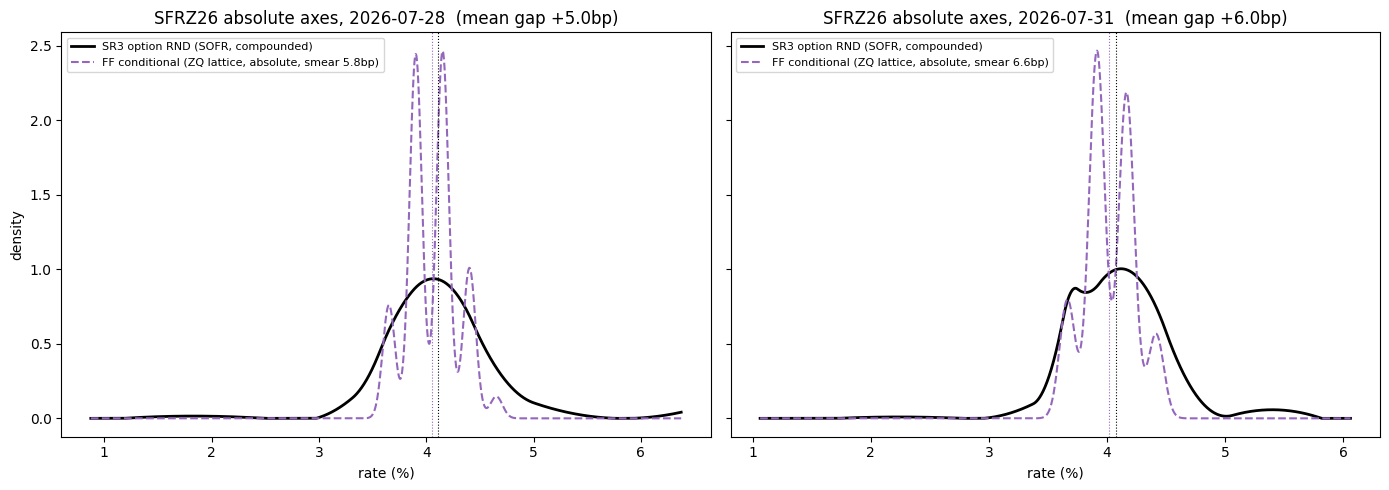

In [12]:
# The absolute view: the option RND on its own axis vs the FF conditional
# distribution anchored at EFFR + the lattice path. The horizontal offset IS
# the ICS decomposition — nothing is pinned away.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, d in zip(axes, (D0, D1)):
    bl = snaps[(ICS_SYM, d)].bl_result
    ax.plot(bl.strike_grid_rate, bl.rnd_density, lw=2, color="k",
            label="SR3 option RND (SOFR, compounded)")
    rates, probs, smear_raw, mean, _ = ff_view[d]
    smear = float(np.sqrt(smear_raw ** 2 + BASIS_SMEAR_BP ** 2))
    ax.plot(bl.strike_grid_rate, mix_pdf(bl.strike_grid_rate, rates, probs, smear),
            "--", color="tab:purple", lw=1.5,
            label=f"FF conditional (ZQ lattice, absolute, smear {smear:.1f}bp)")
    ax.axvline(bl.input.forward_rate, color="k", lw=0.8, ls=":")
    ax.axvline(mean, color="tab:purple", lw=0.8, ls=":")
    gap = (bl.input.forward_rate - mean) * 100
    ax.set_title(f"{ICS_SYM} absolute axes, {d}  (mean gap {gap:+.1f}bp)")
    ax.set_xlabel("rate (%)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

In [13]:
# Is there a trade? Both channels, priced with listed conventions.
r0, r1 = ics_table.iloc[0], ics_table.iloc[1]
tails0 = tails[(ICS_SYM, D0)]
print("CHANNEL 1 — the level (the listed ICS, 10 SR3 : 3+3 ZQ, $250/bp):")
print(f"  observed {r0.ics_bp:.1f}bp -> {r1.ics_bp:.1f}bp; decomposed fair "
      f"(basis+compounding-wedge) {r0.basis_bp + r0.compounding_bp - r0.proxy_wedge_bp:.1f}"
      f" / {r1.basis_bp + r1.compounding_bp - r1.proxy_wedge_bp:.1f}bp; "
      f"residual {r0.residual_bp:+.1f} -> {r1.residual_bp:+.1f}bp.")
print("  The residual on a DECEMBER quarterly contains the year-end turn "
      "premium (the turn sits inside the window), so it is not cleanly "
      "harvestable; and the serff fair-value study already ran this class of "
      "trade with a 3-layer model — costs dominated. Fading the residual is "
      "only interesting if it exceeds a few bp AND the turn is hedged "
      "(e.g. vs the adjacent non-turn quarterly's residual).")
print("\nCHANNEL 2 — the shape (options vs the FF lattice):")
print(f"  the surface prices {tails0[0] + tails0[1]:.0f}pp more off-lattice "
      f"mass than the tree ({tails0[0]:+.1f} below, {tails0[1]:+.1f} above "
      "at 07-28). Selling it is selling insurance against intermeeting / "
      ">25bp outcomes: the SR3 options lab measured the same premium "
      "(+21pp vs the FedWatch null) and its short-vol harvest REVERSED SIGN "
      "when front contracts entered the sample; the meeting-prob backtest "
      "found the tradeable convergence flavour is episodic and cost-bound "
      "at EOD. Nothing in this notebook overturns those verdicts.")
print("\nNET: the honest trade inventory from this triangle is (i) the "
      "listed ICS when the residual decomposition — not the raw spread — "
      "signals, sized at 10:6, with the turn hedged; and (ii) the <60-dte "
      "convergence channel from the meeting-prob study, for which the swap "
      "ladder built here is the cleaner linear leg. Neither is a standing "
      "harvest; both are episodic and cost-gated.")

CHANNEL 1 — the level (the listed ICS, 10 SR3 : 3+3 ZQ, $250/bp):
  observed 5.2bp -> 5.2bp; decomposed fair (basis+compounding-wedge) 3.9 / 3.8bp; residual +1.3 -> +1.4bp.
  The residual on a DECEMBER quarterly contains the year-end turn premium (the turn sits inside the window), so it is not cleanly harvestable; and the serff fair-value study already ran this class of trade with a 3-layer model — costs dominated. Fading the residual is only interesting if it exceeds a few bp AND the turn is hedged (e.g. vs the adjacent non-turn quarterly's residual).

CHANNEL 2 — the shape (options vs the FF lattice):
  the surface prices 16pp more off-lattice mass than the tree (+10.3 below, +5.9 above at 07-28). Selling it is selling insurance against intermeeting / >25bp outcomes: the SR3 options lab measured the same premium (+21pp vs the FedWatch null) and its short-vol harvest REVERSED SIGN when front contracts entered the sample; the meeting-prob backtest found the tradeable convergence flavou

## Summary

Every claim below is computed in this notebook, above.

* **The three linear sources tie out on the mean path** (cumulative moves
  agree to ~1bp) but disagree on per-meeting attribution by up to ~4bp —
  the exchangeability degeneracy, visible between two LINEAR markets, so it
  is a property of measurement, not of options.
* **The swap ladder is the more robust linear source**: no FedWatch
  bootstrap, no month-end weight dilution, no contract-expiry seam — the ZQ
  ladder needed the expired ZQN26 force-refreshed to even see the pending
  July meeting, and it still cannot price it on the decision's eve without
  that contract.
* **Mode structure is extraction-fragile, width is not**: mode count flips
  with the strike filter (Taboga's jaggedness warning applies even here,
  where modes are structurally real) while the recovered std moves ~1bp.
  With 6-14bp of unresolved-meeting smear, on-atom modes only crystallize
  robustly inside the final month; at these vintages the width and tails
  carry the lattice information.
* **The option surface prices more width than any linear tree can carry**,
  and both off-lattice tails are rich on every (symbol, date) — the
  standing channel-2 premium, re-derived through a third, bootstrap-free
  market.
* **Across the July decision** the linear legs show the mechanics
  (front-level collapse, back-jump inflation); the option mean follows the
  forward by parity while the width compresses ~7bp.
* **The listed ICS re-opens the level channel**: `0.5·ZQF27+0.5·ZQG27 −
  SR3Z26` decomposes into basis + compounding + calendar-proxy wedge +
  residual, and the residual on a December quarterly carries the year-end
  turn. The trade inventory is episodic and cost-gated: fade the DECOMPOSED
  residual (turn-hedged, 10:6) when it signals, and run the <60-dte
  convergence channel with the swap ladder as the linear leg.